In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
from GmGM import GmGM
from gprofiler import GProfiler
import warnings
import os
import shutil
from utilities import plot_graph
import matplotlib.pyplot as plt
from scipy import sparse, io, stats
import warnings
from pybiomart import Dataset
from sklearn import metrics
import matplotlib.transforms as transforms
from matplotlib.patches import Patch
from balanced_clustering import balanced_adjusted_mutual_info, balanced_homogeneity, balanced_completeness
import igraph as ig

In [2]:
adata = ad.read_h5ad("results/gmgm_pathway/anndata.h5ad")
adata.var["ID"] = adata.var_names
adata

AnnData object with n_obs × n_vars = 6876 × 29324
    obs: 'source', 'm114_mean', 'm114_percent', 'm37_mean', 'm37_percent', 'm95_mean', 'm95_percent', 'm54_mean', 'm54_percent', 'm12_mean', 'm12_percent', 'm93_mean', 'm93_percent', 'm4_mean', 'm4_percent', 'm15_mean', 'm15_percent', 'm52_mean', 'm52_percent', 'm22_mean', 'm22_percent', 'm57_mean', 'm57_percent', 'm17_mean', 'm17_percent', 'm101_mean', 'm101_percent', 'm70_mean', 'm70_percent', 'm48_mean', 'm48_percent', 'm6_mean', 'm6_percent', 'm79_mean', 'm79_percent', 'm50_mean', 'm50_percent', 'm38_mean', 'm38_percent', 'm108_mean', 'm108_percent', 'm47_mean', 'm47_percent', 'm40_mean', 'm40_percent', 'm82_mean', 'm82_percent', 'm92_mean', 'm92_percent', 'm74_mean', 'm74_percent', 'm3_mean', 'm3_percent', 'm58_mean', 'm58_percent', 'm111_mean', 'm111_percent', 'm89_mean', 'm89_percent', 'm0_mean', 'm0_percent', 'm1_mean', 'm1_percent', 'm30_mean', 'm30_percent', 'm10_mean', 'm10_percent', 'm23_mean', 'm23_percent', 'm44_mean', 'm4

# Run the GmGM and kNN classifications

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


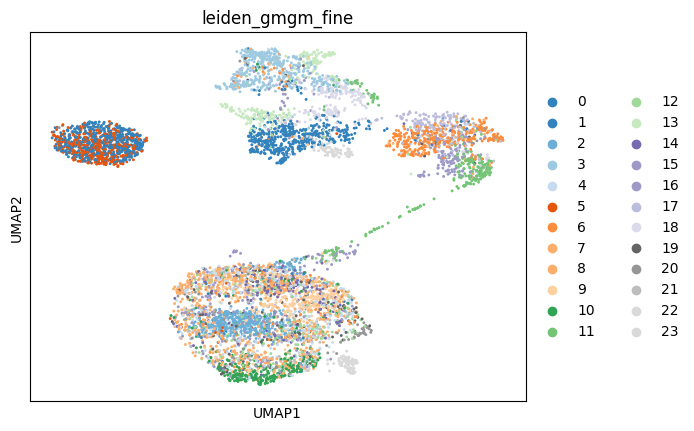

In [3]:
if 'leiden_gmgm_fine_colors' in adata.uns:
    del adata.uns['leiden_gmgm_fine_colors']
sc.tl.leiden(adata, resolution=1, key_added='leiden_gmgm_fine', adjacency=adata.obsp['obs_gmgm_connectivities'])
sc.pl.umap(adata, color=['leiden_gmgm_fine'], palette='tab20c')

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


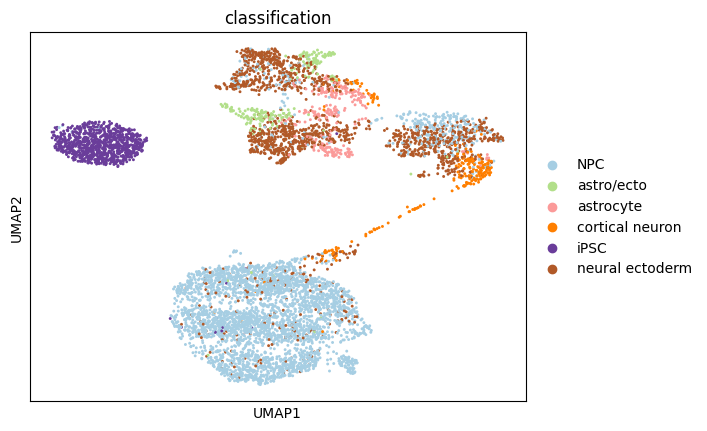

In [4]:
assignments = {
    "c0": "iPSC",
    "c2": "NPC",
    "c4": "NPC",
    "c6": "neural ectoderm",
    "c5": "iPSC",
    "c8": "NPC",
    "c10": "NPC",
    "c11": "cortical neuron",
    "c16": "NPC",
    "c21": "NPC",
    "c23": "NPC"
}
unsure_assignments = {
    "c1": "neural ectoderm",
    "c3": "neural ectoderm",
    "c7": "NPC",
    "c9": "NPC",
    "c12": "NPC",
    "c13": "astro/ecto",
    "c14": "NPC",
    "c15": "neural ectoderm",
    "c17": "NPC",
    "c18": "astrocyte",
    "c19": "NPC",
    "c20": "NPC",
    "c22": "astrocyte"
}
adata.obs["cleiden_gmgm_fine"] = "c" + adata.obs["leiden_gmgm_fine"].astype(str)
adata.obs["classification"] = adata.obs["cleiden_gmgm_fine"].map(assignments | unsure_assignments).fillna("Unknown")
sc.pl.umap(adata, color=['classification'], palette='Paired')

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDepre

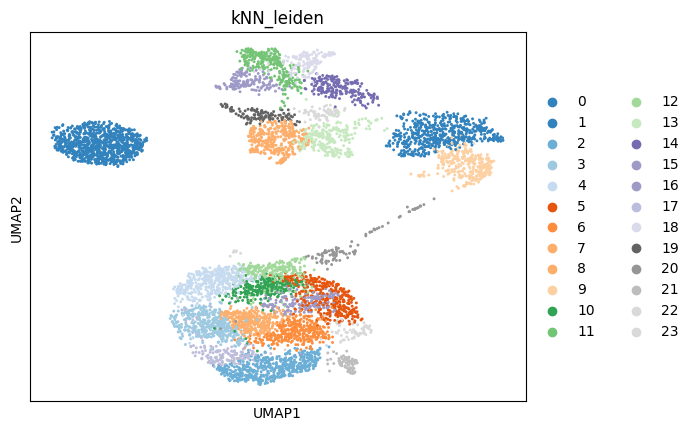

In [5]:
# Cluster cells
sc.pp.highly_variable_genes(adata, n_top_genes=2200)
hvgdata = adata[:, adata.var['highly_variable']]
sc.pp.neighbors(hvgdata)
sc.tl.leiden(hvgdata, resolution=2, key_added="kNN_leiden") # resolution chosen to have same clusters as GmGM
adata.obs['kNN_leiden'] = hvgdata.obs['kNN_leiden']
sc.pl.umap(adata, color=['kNN_leiden'], palette='tab20c')

In [6]:
adata.var_names = adata.var['external_gene_name'].astype('str')
adata.var_names_make_unique()

In [7]:
sc.tl.rank_genes_groups(adata, groupby="kNN_leiden", key_added="knn_ranks")

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/tools/_ran

In [8]:
marker_genes = {
    'iPSC-james': ['NANOG', 'POU5F1', 'LIN28A', 'DPPA4', 'TDGF1', 'ZSCAN10', 'UTF1'],
    'NPC-james': ['PAX6', 'HES1', 'NES', 'MSI1', 'VIM', 'FABP7'],
    'cortical-james': ['TBR1', 'BCL11B', 'MAP2', 'RBFOX3', 'SLC17A7', 'SYT1', 'GRIN2B'],
    'astro-james': ['NFIA', 'SOX9', 'GFAP', 'AQP4', 'S100B', 'ALDH1L1', 'GLUL'] + ['SLC1A3', 'SLC1A2'],
    'oligo-james': ['SOX10', 'MYRF', 'MBP', 'MOG', 'PLP1', 'MAG', 'CNP'],
    'ecto-james': ['SOX1', 'ZIC1', 'OTX2', 'LHX2', 'EMX2', 'DACH1', 'SIX3'],
    'micro-james': ['IRF8', 'SPI1', 'MAFB', 'SALL1', 'TMEM119', 'P2RY12', 'CX3CR1', 'TREM2', 'GPR34', 'SIGLECH']
}
for marker, genes in marker_genes.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"{marker}_score")
results = sc.tl.marker_gene_overlap(adata, marker_genes, key="knn_ranks")
results.columns = [f"l{x}" for x in range(24)]
results

,l0,l1,l2,l3,l4,l5,l6,l7,l8,l9,...,l14,l15,l16,l17,l18,l19,l20,l21,l22,l23
iPSC-james,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
NPC-james,0.0,0.0,2.0,2.0,0.0,1.0,2.0,0.0,2.0,0.0,...,0.0,1.0,0.0,2.0,0.0,0.0,0.0,3.0,2.0,0.0
cortical-james,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,...,1.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0
astro-james,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
oligo-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ecto-james,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,...,2.0,0.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
micro-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


""
iPSC-james
NPC-james
cortical-james
astro-james
oligo-james
ecto-james
micro-james


/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


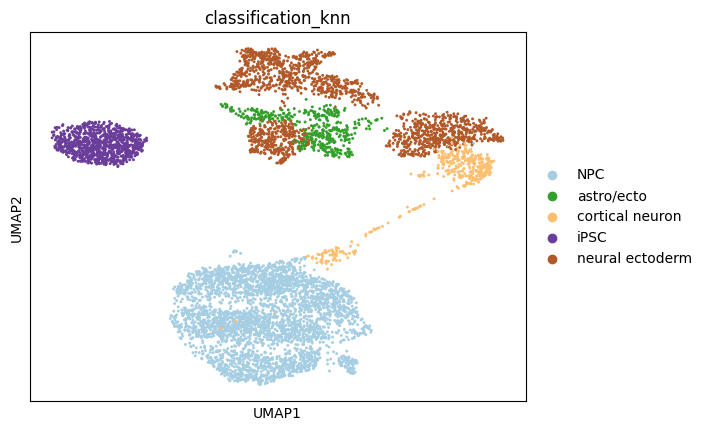

In [9]:
assignments = {
    "l0": "iPSC",
    "l1": "neural ectoderm",
    "l2": "NPC",
    "l3": "NPC",
    "l6": "NPC",
    "l7": "neural ectoderm",
    "l8": "NPC",
    "l9": "cortical neuron",
    "l10": "NPC",
    "l11": "neural ectoderm",
    "l12": "NPC",
    "l13": "astro/ecto",
    "l14": "neural ectoderm",
    "l16": "neural ectoderm",
    "l17": "NPC",
    "l18": "neural ectoderm",
    "l19": "astro/ecto",
    "l20": "cortical neuron",
    "l21": "NPC",
    "l22": "NPC",
    "l23": "astro/ecto",
    # Expression
    "l4": "NPC",
    "l5": "NPC",
    "l15": "NPC"
}
adata.obs["cleiden_knn"] = "l" + adata.obs["kNN_leiden"].astype(str)
adata.obs["classification_knn"] = adata.obs["cleiden_knn"].map(assignments).fillna("Unknown")
display(results[[x for x in results.columns if x not in assignments.keys()]])
sc.pl.umap(adata, color=['classification_knn'], palette='Paired')

# Compare the classifications

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_

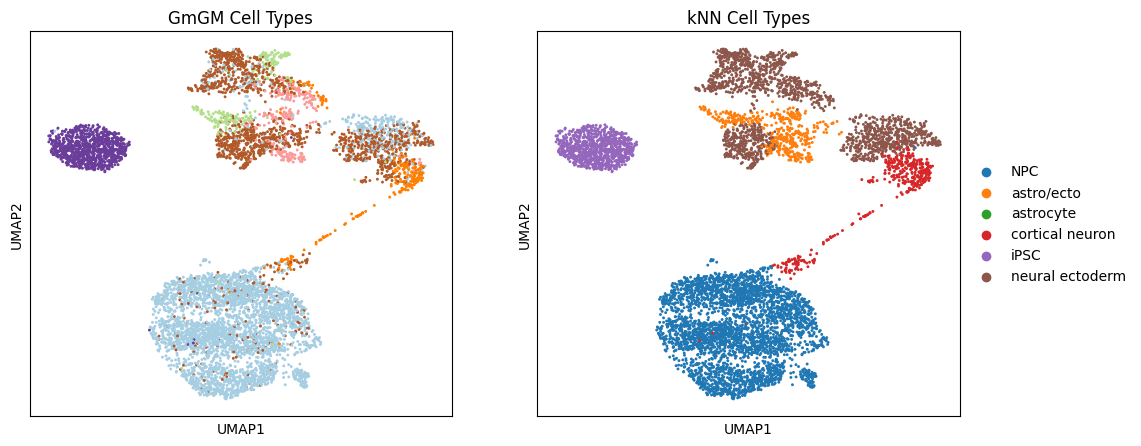

In [10]:
for category in adata.obs['classification'].cat.categories:
    if category not in adata.obs['classification_knn'].cat.categories:
        adata.obs['classification_knn'] = adata.obs['classification_knn'].cat.add_categories(category)
adata.obs['classification_knn'] = adata.obs['classification_knn'].cat.reorder_categories(
    adata.obs['classification'].cat.categories
)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.umap(adata, color='classification', ax=axs[0], show=False, legend_loc=None, title="GmGM Cell Types")
sc.pl.umap(adata, color='classification_knn', ax=axs[1], show=False, legend_loc='right margin', title="kNN Cell Types")

plt.show()

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


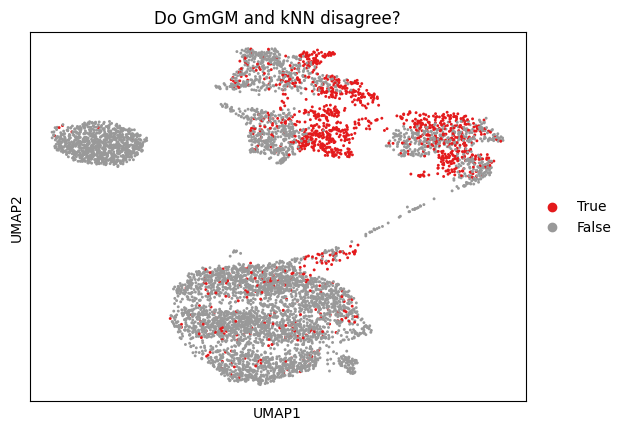

In [11]:
adata.obs['disagreement'] = (adata.obs['classification'] != adata.obs['classification_knn']).astype('category')
adata.obs['disagreement'] = adata.obs['disagreement'].cat.reorder_categories([True, False])
sc.pl.umap(adata, color='disagreement', title='Do GmGM and kNN disagree?', palette='Set1')

kNN has about twice as many cells labeled as "astro/ecto".

In [12]:
print(adata.obs['classification'].value_counts()['astro/ecto'] / adata.shape[0])
print(adata.obs['classification_knn'].value_counts()['astro/ecto'] / adata.shape[0])

0.03228621291448516
0.06428155904595695


Are the non-NPC GmGM cells truly non-NPC?

In [13]:
adata.obs['p2p3-non-npc'] = (
    adata.obs['source'].isin(['NPC_p2', 'NPC_p3'])
    & ~adata.obs['classification'].isin(['NPC'])
).astype('category').cat.rename_categories({True: 'p2p3 non-NPC', False: 'not p2p3'})
adata.obs['p2p3-non-npc'] = adata.obs['p2p3-non-npc'].cat.add_categories(['p2p3 NPC'])
adata.obs.loc[
    adata.obs['source'].isin(['NPC_p2', 'NPC_p3'])
    & adata.obs['classification'].isin(['NPC']),
    'p2p3-non-npc'
] = "p2p3 NPC"
adata.obs['p2p3-non-npc'].value_counts()

p2p3-non-npc
not p2p3        3353
p2p3 NPC        3256
p2p3 non-NPC     267
Name: count, dtype: int64

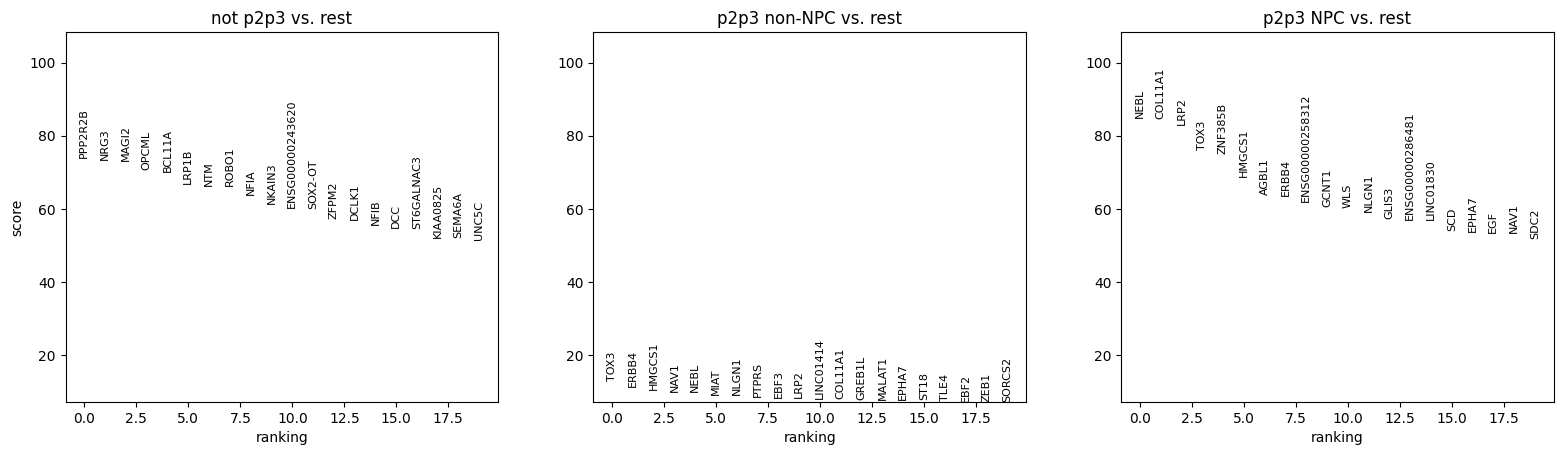

In [14]:
sc.tl.rank_genes_groups(adata, groupby='p2p3-non-npc', key_added='p2p3-ranks')
sc.pl.rank_genes_groups(adata, key='p2p3-ranks')

In [15]:
results_p2p3 = sc.tl.marker_gene_overlap(adata, marker_genes, key="p2p3-ranks")
results_p2p3

,not p2p3,p2p3 non-NPC,p2p3 NPC
iPSC-james,0.0,0.0,0.0
NPC-james,0.0,1.0,3.0
cortical-james,0.0,1.0,0.0
astro-james,1.0,0.0,0.0
oligo-james,0.0,0.0,0.0
ecto-james,0.0,0.0,0.0
micro-james,0.0,0.0,0.0


Great - so these oddball cells express both cortical and NPC markers - which ones?

In [16]:
relevant_marker_genes = {
    'NPC-james': ['PAX6', 'HES1', 'NES', 'MSI1', 'VIM', 'FABP7'],
    'cortical-james': ['TBR1', 'BCL11B', 'MAP2', 'RBFOX3', 'SLC17A7', 'SYT1', 'GRIN2B'],
}
relevant_marker_genes

{'NPC-james': ['PAX6', 'HES1', 'NES', 'MSI1', 'VIM', 'FABP7'],
 'cortical-james': ['TBR1',
  'BCL11B',
  'MAP2',
  'RBFOX3',
  'SLC17A7',
  'SYT1',
  'GRIN2B']}

In [17]:
import pandas as pd

ranks = adata.uns["p2p3-ranks"]

top_n = 100

overlap_dict = {}

for group in ranks["names"].dtype.names:
    genes = pd.Series(ranks["names"][group])
    pvals = pd.Series(ranks["pvals_adj"][group])

    df = pd.DataFrame({"gene": genes, "pval_adj": pvals}).dropna()

    # filter for significance
    df = df[df["pval_adj"] < 0.05]

    # optional: restrict to top N
    if top_n is not None:
        df = df.head(top_n)

    sig_genes = df["gene"]

    for celltype, markers in relevant_marker_genes.items():
        overlap = set(sig_genes).intersection(markers)

        if overlap:
            overlap_dict[(group, celltype)] = sorted(overlap)

overlap_dict

{('p2p3 non-NPC', 'NPC-james'): ['VIM'],
 ('p2p3 non-NPC', 'cortical-james'): ['MAP2'],
 ('p2p3 NPC', 'NPC-james'): ['NES', 'PAX6', 'VIM']}

Make a version of the classification vs m13 plot to also include kNN

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_

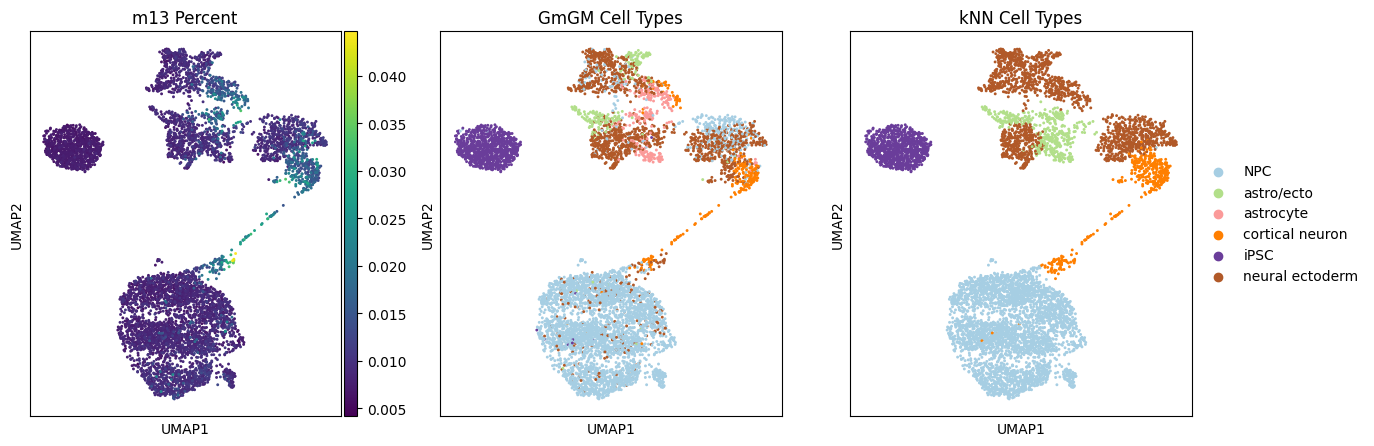

In [18]:
for category in adata.obs['classification'].cat.categories:
    if category not in adata.obs['classification_knn'].cat.categories:
        adata.obs['classification_knn'] = adata.obs['classification_knn'].cat.add_categories(category)
adata.obs['classification_knn'] = adata.obs['classification_knn'].cat.reorder_categories(
    adata.obs['classification'].cat.categories
)
adata.uns['classification_knn_colors'] = adata.uns['classification_colors']
fig, axs = plt.subplots(figsize=(15, 5), ncols=3)

sc.pl.umap(adata, color='classification', ax=axs[1], show=False, legend_loc=None, title="GmGM Cell Types")
sc.pl.umap(adata, color='classification_knn', ax=axs[2], show=False, legend_loc='right margin', title="kNN Cell Types")
sc.pl.umap(adata, color='m13_percent', ax=axs[0], show=False, legend_loc=None, title="m13 Percent")
plt.savefig('./figures/m13-percent-updated.png', bbox_inches='tight')
plt.show()

In [29]:
print(adata[adata.obs['p2p3-non-npc'] == 'p2p3 non-NPC'].shape[0])
adata[adata.obs['p2p3-non-npc'] == 'p2p3 non-NPC'].obs['classification'].value_counts()

267


classification
neural ectoderm    196
cortical neuron     44
iPSC                19
astro/ecto           7
astrocyte            1
Name: count, dtype: int64

# What about using the single-axis equivalen to GmGM?

In [30]:
X = hvgdata.X
X.shape

(6876, 2200)

In [31]:
def keep_top_k_per_row(X, k=5):
    sgn_X = np.sign(X)
    X = np.abs(X)
    n = X.shape[0]
    
    # Find indices of top-k per row
    idx = np.argpartition(X, -k, axis=1)[:, -k:]
    
    # Build mask
    mask = np.zeros_like(X, dtype=bool)
    rows = np.arange(n)[:, None]
    mask[rows, idx] = True
    
    # Zero out everything else
    X[~mask] = 0
    X *= sgn_X
    X += X.T
    return sparse.csr_array(X)

In [ ]:
S_cells = 1.0 * (keep_top_k_per_row(np.linalg.pinv(X@X.T)) != 0)
S_cells

<6876x6876 sparse array of type '<class 'numpy.float64'>'
	with 68735 stored elements in Compressed Sparse Row format>

In [39]:
# resolution chosen to have same clusters as GmGM
sc.tl.leiden(adata, resolution=2.15, key_added="basic_leiden", adjacency=S_cells)
adata.obs['basic_leiden'].value_counts()

basic_leiden
0     672
1     569
2     536
3     498
4     398
5     376
6     359
7     349
8     347
9     337
10    310
11    295
12    275
13    239
14    203
15    185
16    184
17    179
18    171
19    136
20    132
21     89
22     34
23      3
Name: count, dtype: int64

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


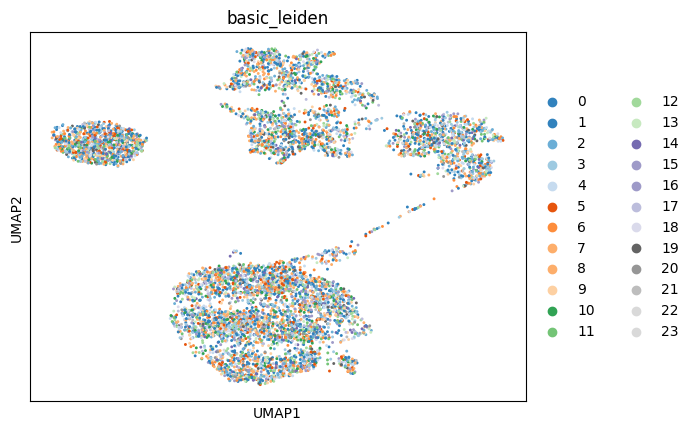

In [40]:
if 'basic_leiden_colors' in adata.uns:
    del adata.uns['basic_leiden_colors']
sc.pl.umap(adata, color=['basic_leiden'], palette='tab20c')

In [41]:
sc.tl.rank_genes_groups(adata, groupby="basic_leiden", key_added="basic_ranks")

/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/Users/baileyandrew/mambaforge/envs/cnr-colab/lib/python3.9/site-packages/scanpy/tools/_ran

In [43]:
marker_genes = {
    'iPSC-james': ['NANOG', 'POU5F1', 'LIN28A', 'DPPA4', 'TDGF1', 'ZSCAN10', 'UTF1'],
    'NPC-james': ['PAX6', 'HES1', 'NES', 'MSI1', 'VIM', 'FABP7'],
    'cortical-james': ['TBR1', 'BCL11B', 'MAP2', 'RBFOX3', 'SLC17A7', 'SYT1', 'GRIN2B'],
    'astro-james': ['NFIA', 'SOX9', 'GFAP', 'AQP4', 'S100B', 'ALDH1L1', 'GLUL'] + ['SLC1A3', 'SLC1A2'],
    'oligo-james': ['SOX10', 'MYRF', 'MBP', 'MOG', 'PLP1', 'MAG', 'CNP'],
    'ecto-james': ['SOX1', 'ZIC1', 'OTX2', 'LHX2', 'EMX2', 'DACH1', 'SIX3'],
    'micro-james': ['IRF8', 'SPI1', 'MAFB', 'SALL1', 'TMEM119', 'P2RY12', 'CX3CR1', 'TREM2', 'GPR34', 'SIGLECH']
}
results_basic = sc.tl.marker_gene_overlap(adata, marker_genes, key="basic_ranks")
results_basic.columns = [f"b{x}" for x in range(24)]
results_basic

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,b14,b15,b16,b17,b18,b19,b20,b21,b22,b23
iPSC-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NPC-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
cortical-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
astro-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
oligo-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ecto-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
micro-james,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
results_basic.loc[:, (results_basic.sum(axis=0) != 0).to_numpy()]

,b14,b22
iPSC-james,0.0,0.0
NPC-james,0.0,1.0
cortical-james,0.0,1.0
astro-james,0.0,0.0
oligo-james,0.0,0.0
ecto-james,1.0,0.0
micro-james,0.0,0.0


So all except two clusters are not statistically related to any cell types!

In [52]:
unknowns = adata[adata.obs['basic_leiden'].isin(results_basic.columns[(results_basic.sum(axis=0) == 0)].str[1:])].shape[0]
unknowns / adata.shape[0]

0.9655322862129145